# Blue Carbon Guardian: tide-aware mangrove monitoring (main analysis)

**Team T0006 · Arab Youth Space Hackathon 2026, Challenge 813 · Theme: Ecosystem Health, Biodiversity & Blue Carbon**

This notebook reproduces the headline results of the proof of concept from the small example input in `data/sample_input/`, which is real Sentinel-2 L2A
data for 25 mangrove stands near Abu Dhabi, 2020-2026:

1. **The tide is the main source of noise**, and modelling it removes about a third of the date-to-date noise.
2. **Stand condition:** each stand against its own 2020-21 baseline. Stand 5 shows a severe decline: a coastal development.
3. **200 m cells expose partial losses** that a stand average hides (stands 9, 12 and 18).
4. **The product alert** ("stand average OR any 200 m cell", about 1 false alarm per stand-year) fires between the last undisturbed and the first disturbed
   sub-metre capture at each converted site.
5. **Carbon stock** per stand from field-measured density, with a range.

Runtime: about 2-4 minutes on a laptop, no GPU, no internet, no credentials. Outputs are written to `results/`.
Data: "Contains modified Copernicus Sentinel data 2020-2026" (ESA/Copernicus via Microsoft Planetary Computer); stand outlines from ESA WorldCover 2021 (CC BY 4.0).

In [1]:
from pathlib import Path
import sys, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()     # works from the repo root or from notebooks/
sys.path.insert(0, str(ROOT / "src"))
from bcg import monitor as M

np.random.seed(0)                                   # no step is random; set for completeness
IN, OUT = ROOT / "data" / "sample_input", ROOT / "results"
OUT.mkdir(exist_ok=True)
pd.set_option("display.width", 160)

stands = pd.read_csv(IN / "stands.csv")
S = pd.read_csv(IN / "s2_stand_series.csv", parse_dates=["date"])
cells_meta = pd.read_csv(IN / "cells_stands_9_12_18.csv")
C = pd.read_csv(IN / "s2_cell_series_stands_9_12_18.csv", parse_dates=["date"])
print(f"{len(stands)} stands, {stands.area_ha.sum():,.0f} ha | {S.date.nunique()} Sentinel-2 dates {S.date.min():%Y-%m-%d} .. {S.date.max():%Y-%m-%d}")
print(f"{len(cells_meta)} cells of 200 m in stands 9, 12, 18 | {len(C):,} cell-date rows")

25 stands, 2,281 ha | 770 Sentinel-2 dates 2020-01-04 .. 2026-09-17
64 cells of 200 m in stands 9, 12, 18 | 43,749 cell-date rows


## 1. The tide is the main source of noise
Mangroves here sit on tidal flats: water under the canopy lowers NDVI and NDMI on high-tide dates. We fit each stand's index with and without the tide terms
(MNDWI, MNDWI², flooded fraction) and compare the robust residual noise.

,noise_without_tide,noise_with_tide,reduction_%
index,,,
ndmi,0.0432,0.0306,29.3
ndre,0.0283,0.0183,35.3
ndvi,0.0436,0.0298,31.6


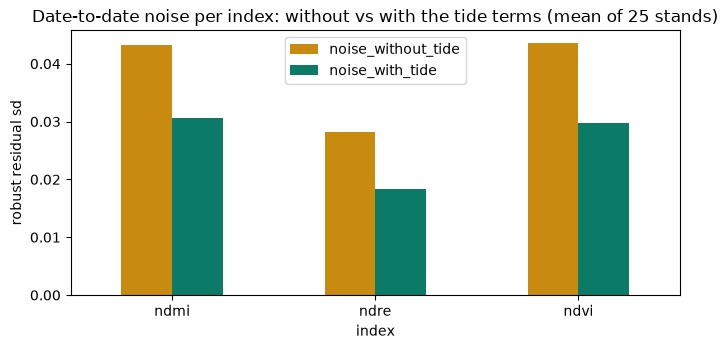

In [2]:
rows = []
SER = {k: M.to_series(g) for k, g in S.groupby("stand")}
for k, s in SER.items():
    for i in M.IDX:
        s0, s1 = M.noise_with_without_tide(s, i)
        rows.append(dict(stand=k, index=i, noise_without_tide=s0, noise_with_tide=s1))
noise = pd.DataFrame(rows).groupby("index")[["noise_without_tide", "noise_with_tide"]].mean()
noise["reduction_%"] = (100 * (1 - noise.noise_with_tide / noise.noise_without_tide)).round(1)
noise.round(4).to_csv(OUT / "01_tide_noise.csv")
display(noise.round(4))

ax = noise[["noise_without_tide", "noise_with_tide"]].plot.bar(rot=0, figsize=(7, 3.6), color=["#C98A10", "#0B7A66"])
ax.set_ylabel("robust residual sd"); ax.set_title("Date-to-date noise per index: without vs with the tide terms (mean of 25 stands)")
plt.tight_layout(); plt.savefig(OUT / "01_tide_noise.png", dpi=110); plt.show()

## 2. Stand condition against each stand's own baseline
Tide-corrected NDVI and NDMI: median of the last 12 months (a full seasonal cycle) against the 2020-21 median.
Classes: severe decline (both at or below -50 %), decline (both at or below -15 % and -3 sigma), improving (the mirror rule), otherwise stable.

condition
stable            24
severe decline     1


,stand,area_ha,ndvi_base,ndvi_now,ndvi_change_pct,ndmi_change_pct,condition
4,5,176.5,0.274,-0.030,-111.0,-104.0,severe decline
11,12,75.9,0.358,0.273,-23.8,-24.1,stable
0,1,205.4,0.249,0.199,-19.9,-28.8,stable
24,25,27.3,0.577,0.517,-10.5,-24.2,stable
8,9,99.2,0.402,0.360,-10.4,-14.8,stable
21,22,30.9,0.552,0.503,-8.8,-8.7,stable


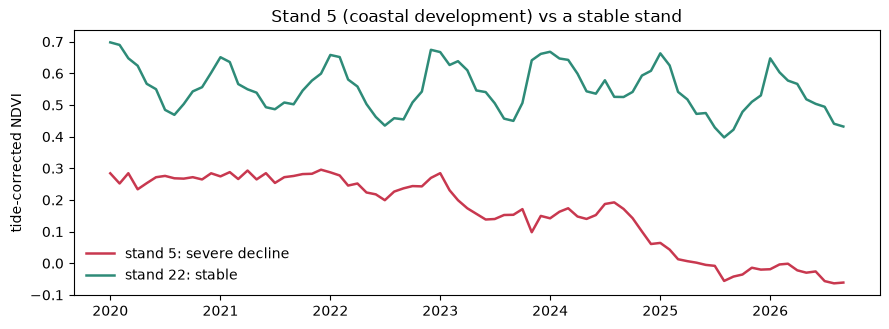

In [3]:
cond = pd.DataFrame([dict(stand=k, **M.condition(s)) for k, s in SER.items()]).merge(stands[["stand", "area_ha"]], on="stand")
cond.to_csv(OUT / "02_stand_condition.csv", index=False)
print(cond.condition.value_counts().to_string())
display(cond.sort_values("ndvi_change_pct").head(6)[["stand", "area_ha", "ndvi_base", "ndvi_now", "ndvi_change_pct", "ndmi_change_pct", "condition"]])

fig, ax = plt.subplots(figsize=(9, 3.4))
for k, col in ((5, "#C8384F"), (22, "#2E8B78")):
    s = SER[k]; X = M.design(s["t"], s["w"], s["ff"]); beta, _ = M.rfit(X, s["y"]["ndvi"])
    corr = s["y"]["ndvi"] - X[:, 6:] @ beta[6:] + (X[:, 6:] @ beta[6:]).mean()
    d = pd.Series(corr, index=M.T0 + pd.to_timedelta(s["t"], unit="D")).resample("MS").median()
    ax.plot(d.index, d.values, color=col, lw=1.8, label=f"stand {k}: {cond.set_index('stand').loc[k, 'condition']}")
ax.set_ylabel("tide-corrected NDVI"); ax.legend(frameon=False); ax.set_title("Stand 5 (coastal development) vs a stable stand")
plt.tight_layout(); plt.savefig(OUT / "02_stand5_vs_stable.png", dpi=110); plt.show()

## 3. 200 m cells expose partial losses
Each stand is cut into 200 m x 200 m cells, and the same condition rule runs per cell. The stand average can read "stable" while a part of the stand is
gone. Squares are drawn at each cell's position on the Sentinel-2 grid (north up).

,cells,flagged_cells,flagged_ha,stand_average_condition
stand,,,,
9,28,8,21.8,stable
12,20,6,13.2,stable
18,16,3,5.1,stable


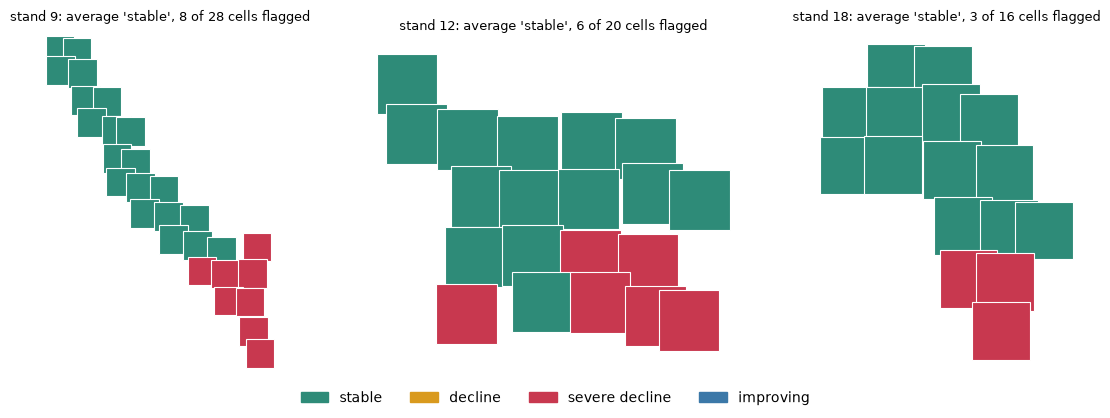

In [4]:
CSER = {c: M.to_series(g) for c, g in C.groupby("cell")}
cc = pd.DataFrame([dict(cell=c, **M.condition(s)) for c, s in CSER.items()]).merge(cells_meta, on="cell")
cc["area_ha"] = cc.n_px * 0.01
cc.to_csv(OUT / "03_cell_condition.csv", index=False)
summary = (cc.assign(flagged=cc.condition.isin(["decline", "severe decline"]))
             .groupby("stand").agg(cells=("cell", "size"), flagged_cells=("flagged", "sum"),
                                    flagged_ha=("area_ha", lambda a: a[cc.loc[a.index, "condition"].isin(["decline", "severe decline"])].sum()))
             .join(cond.set_index("stand")[["condition"]].rename(columns={"condition": "stand_average_condition"})))
display(summary.round(1))

colors = {"stable": "#2E8B78", "decline": "#D99A1E", "severe decline": "#C8384F", "improving": "#3B78A8"}
fig, axs = plt.subplots(1, 3, figsize=(12, 4.2))
for a, k in zip(axs, (9, 12, 18)):
    d = cc[cc.stand == k]
    for r in d.itertuples():
        a.add_patch(plt.Rectangle((r.col - 10, -r.row - 10), 20, 20, color=colors[r.condition], ec="white", lw=0.8))
    a.set_xlim(d.col.min() - 15, d.col.max() + 15); a.set_ylim(-d.row.max() - 15, -d.row.min() + 15); a.set_aspect("equal"); a.axis("off")
    a.set_title(f"stand {k}: average '{summary.loc[k, 'stand_average_condition']}', {int(summary.loc[k, 'flagged_cells'])} of {int(summary.loc[k, 'cells'])} cells flagged", fontsize=9)
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=v) for v in colors.values()], labels=list(colors), loc="lower center", ncol=4, frameon=False)
plt.tight_layout(rect=(0, 0.06, 1, 1)); plt.savefig(OUT / "03_cells_vs_stand_average.png", dpi=110); plt.show()

## 4. The product alert, and when it fired
Rule: the **stand average** state at or below -1.5 sigma **OR** any **cell** state at or below -3.5 sigma. The state is the median of the last 5 composite
z-scores. The thresholds were calibrated on all 25 pilot stands to about one false-alarm episode per stand-year (`analysis/29_cell_trigger.py`; 0.79 per
stand-year on 65 unseen stands, `analysis/33`).

The converted parts of stands 9, 12 and 18 are bracketed by dated sub-metre captures (WorldView-2/3, Legion-1, Esri World Imagery Wayback;
`analysis/34_vhr_summary.md`). We check whether the alert started inside that window.

,stand,last_undisturbed_capture,first_capture_with_works,alert_episodes_2022_2026,alert_started_in_window,inside_window
0,9,2022-03-28,2023-02-22,4,2022-12-07,True
1,12,2022-03-28,2023-02-22,5,2022-12-17,True
2,18,2023-11-14,2025-01-06,6,2024-10-29,True


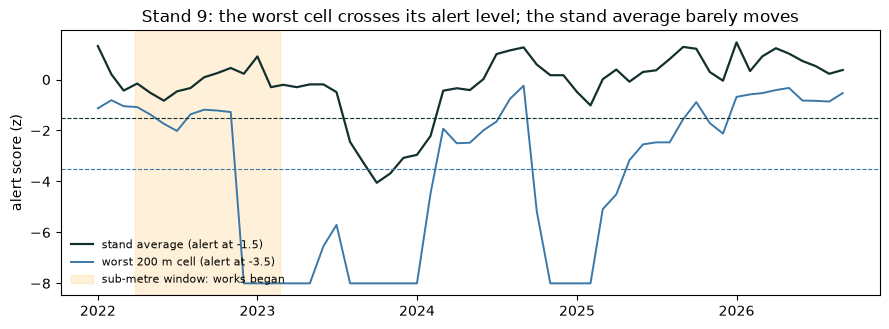

In [5]:
VHR = {9: ("2022-03-28", "2023-02-22"), 12: ("2022-03-28", "2023-02-22"), 18: ("2023-11-14", "2025-01-06")}   # last undisturbed, first disturbed capture
rows, STATES = [], {}
for k in (9, 12, 18):
    ids = cells_meta[cells_meta.stand == k].cell.tolist()
    proxy = M.stand_proxy([CSER[c] for c in ids], cells_meta[cells_meta.stand == k].n_px.sum())
    stand_state = M.alert_state(proxy); cell_states = [M.alert_state(CSER[c]) for c in ids]
    t, on, on_s, on_c = M.product_alert(stand_state, cell_states); STATES[k] = (stand_state, cell_states)
    lo, hi = (pd.Timestamp(x).date() for x in VHR[k])
    eps = M.episodes(t, on); inside = [e for e in eps if lo <= e[0] <= hi]
    rows.append(dict(stand=k, last_undisturbed_capture=lo, first_capture_with_works=hi, alert_episodes_2022_2026=len(eps),
                     alert_started_in_window=inside[0][0] if inside else None, inside_window=bool(inside)))
timing = pd.DataFrame(rows); timing.to_csv(OUT / "04_alert_timing.csv", index=False); display(timing)

(ts, zs), cs = STATES[9]
fig, ax = plt.subplots(figsize=(9, 3.4))
worst = pd.concat([pd.Series(z, index=M.T0 + pd.to_timedelta(t, unit="D")) for t, z in cs if len(t)], axis=1, sort=True).min(axis=1).resample("MS").median()
stand_m = pd.Series(zs, index=M.T0 + pd.to_timedelta(ts, unit="D")).resample("MS").median()
ax.plot(stand_m.index, stand_m.values, color="#12302E", lw=1.6, label="stand average (alert at -1.5)")
ax.plot(worst.index, worst.clip(lower=-8).values, color="#3B78A8", lw=1.4, label="worst 200 m cell (alert at -3.5)")
ax.axhline(-M.STAND_THR, color="#12302E", ls="--", lw=0.8); ax.axhline(-M.CELL_THR, color="#3B78A8", ls="--", lw=0.8)
ax.axvspan(pd.Timestamp(VHR[9][0]), pd.Timestamp(VHR[9][1]), color="orange", alpha=0.15, label="sub-metre window: works began")
ax.set_ylabel("alert score (z)"); ax.legend(frameon=False, fontsize=8, loc="lower left"); ax.set_title("Stand 9: the worst cell crosses its alert level; the stand average barely moves")
plt.tight_layout(); plt.savefig(OUT / "05_stand9_alert_scores.png", dpi=110); plt.show()

## 5. Carbon stock per stand
Stock = stand area x field-measured carbon density: 108 t C/ha, with a 90 % confidence interval of the mean of 79-138. The density comes from 24 plots at
four sites near the stands (trees plus the top 1 m of soil; Schile et al. 2016, Dryad doi 10.15146/R3K59Z, CC0). This is a **stock**, not a sequestration
rate. For converted stands it is an upper bound, because the outline includes ground that is no longer mangrove.

In [6]:
lo, mid, hi = M.CARBON_T_C_PER_HA
carbon = cond[["stand", "area_ha", "condition"]].assign(stock_kt_C_low=lambda d: d.area_ha * lo / 1000, stock_kt_C=lambda d: d.area_ha * mid / 1000,
                                                         stock_kt_C_high=lambda d: d.area_ha * hi / 1000)
carbon["stock_kt_CO2e"] = carbon.stock_kt_C * M.CO2E
carbon.round(2).to_csv(OUT / "06_carbon_stock.csv", index=False)
tot = carbon[["area_ha", "stock_kt_C_low", "stock_kt_C", "stock_kt_C_high", "stock_kt_CO2e"]].sum()
print(f"25 stands, {tot.area_ha:,.0f} ha: {tot.stock_kt_C:.0f} kt C ({tot.stock_kt_C_low:.0f}-{tot.stock_kt_C_high:.0f}), about {tot.stock_kt_CO2e:.0f} kt CO2e")

25 stands, 2,281 ha: 247 kt C (180-316), about 907 kt CO2e


## Summary and limits
- **Tide correction** cuts the noise of every index by about a third (table 1). This is what makes stand-level monitoring possible on Gulf tidal flats.
- **Stand 5** is the one stand in severe decline (a coastal development). **Stands 9, 12 and 18** read "stable" on average, but have cells in severe decline:
  the converted parts.
- **The product alert** started inside the sub-metre window of first works at every checked site. This is **detection of works as they happen, not advance warning.**
- **Limits:**
  - Sentinel-2 at 10 m: very young plantings and patches under about 0.6 ha are not seen.
  - Stand outlines come from a 2021 land-cover map.
  - The confirmations use dated sub-metre imagery, not site visits.
  - Simulated detection rates (`analysis/29`, `30`) are reported next to their chance rates.

Full pipeline (all 25 + 65 stands, EnMAP hyperspectral check, null backtest, scale-out): see `analysis/README.md`.